# Устранение дисбаланса классов в данных ЭКГ MIT-BIH

В базе MIT-BIH класс **N (Normal)** составляет около **90%** всех сегментов, что приводит к смещению модели в сторону мажоритарного класса. Метрика accuracy теряет смысл так как модель, всегда предсказывающая N, получит 90% точности, не научившись распознавать аритмии.

## Применяемые методы

1. **SMOTE** (Synthetic Minority Oversampling Technique) - генерация синтетических примеров методом интерполяции
2. **Аугментации сигнала** - физически осмысленные искажения ЭКГ (шум, сдвиг, дрейф изолинии и др.)
3. **Взвешенная функция потерь** - повышение веса миноритарных классов при обучении
4. **WeightedRandomSampler** - взвешенная выборка батчей в PyTorch

Эти методы можно использовать как по отдельности, так и в комбинации.

## Входные данные

Ноутбук читает файл `mitbih_preprocessed.npz`, созданный на этапе предобработки, содержащий:
- `X` - массив сегментов ЭКГ, shape `(N_beats, 250)`
- `y` - метки классов AAMI (0-4), shape `(N_beats,)`
- `pids` - идентификаторы пациентов, shape `(N_beats,)`

## 1. Установка и импорт библиотек

In [40]:
# Установка библиотек (раскомментируйте при необходимости)
# !pip install numpy pandas matplotlib scikit-learn imbalanced-learn scipy torch

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
from scipy.interpolate import CubicSpline

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# Фиксируем seed для воспроизводимости
np.random.seed(42)
torch.manual_seed(42)

# Названия классов AAMI
CLASS_NAMES = ['N', 'S', 'V', 'F', 'Q']
CLASS_DESCRIPTIONS = {
    'N': 'Normal - нормальные сокращения',
    'S': 'Supraventricular - наджелудочковые экстрасистолы',
    'V': 'Ventricular - желудочковые экстрасистолы',
    'F': 'Fusion - сливные комплексы',
    'Q': 'Unknown - неизвестные/артефакты'
}

# Частота дискретизации MIT-BIH
FS = 360

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

## 2. Загрузка предобработанных данных

Читаем сохранённый ранее файл `mitbih_preprocessed.npz` и анализируем исходное распределение классов.

In [42]:
# Загрузка данных
data = np.load('./models/mitbih_preprocessed.npz')
X = data['X']       # (N_beats, 250)
y = data['y']       # (N_beats,)
pids = data['pids'] # (N_beats,)

print(f'Форма X:    {X.shape}')
print(f'Форма y:    {y.shape}')
print(f'Форма pids: {pids.shape}')
print(f'Уникальных пациентов: {len(np.unique(pids))}')
print(f'Диапазон значений X: [{X.min():.3f}, {X.max():.3f}]')

Форма X:    (109449, 250)
Форма y:    (109449,)
Форма pids: (109449,)
Уникальных пациентов: 48
Диапазон значений X: [-19.572, 13.722]


In [43]:
def print_distribution(y, title='Распределение классов'):
    """Печатает распределение классов с визуальной шкалой."""
    print(f'\n{title}:')
    print('-' * 55)
    total = len(y)
    for idx, name in enumerate(CLASS_NAMES):
        count = int(np.sum(y == idx))
        pct = 100 * count / total if total > 0 else 0
        bar = '█' * int(pct / 2)
        print(f'  {name}: {count:>7}  ({pct:5.2f}%) {bar}')
    print('-' * 55)
    print(f'  Всего: {total}')

print_distribution(y, 'Исходное распределение всех данных')


Исходное распределение всех данных:
-------------------------------------------------------
  N:   90592  (82.77%) █████████████████████████████████████████
  S:    2781  ( 2.54%) █
  V:    7235  ( 6.61%) ███
  F:     802  ( 0.73%) 
  Q:    8039  ( 7.34%) ███
-------------------------------------------------------
  Всего: 109449


### Визуализация дисбаланса

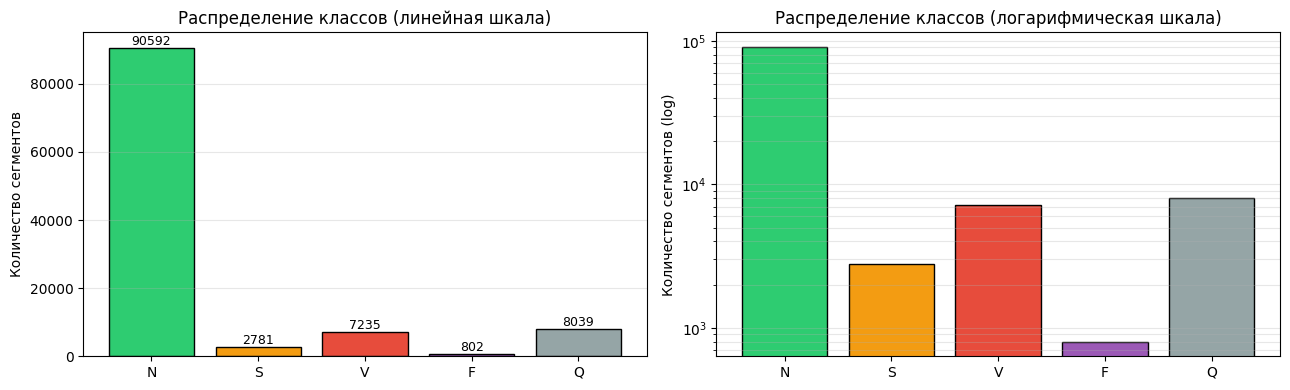


Коэффициент дисбаланса (max/min): 113.0:1


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = [np.sum(y == i) for i in range(5)]
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#95a5a6']

# Столбчатая диаграмма
axes[0].bar(CLASS_NAMES, counts, color=colors, edgecolor='black')
axes[0].set_ylabel('Количество сегментов')
axes[0].set_title('Распределение классов (линейная шкала)')
axes[0].grid(axis='y', alpha=0.3)
for i, c in enumerate(counts):
    axes[0].text(i, c, f'{c}', ha='center', va='bottom', fontsize=9)

# Логарифмическая шкала ? лучше видны миноритарные классы
axes[1].bar(CLASS_NAMES, counts, color=colors, edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_ylabel('Количество сегментов (log)')
axes[1].set_title('Распределение классов (логарифмическая шкала)')
axes[1].grid(axis='y', alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Коэффициент дисбаланса
imbalance_ratio = max(counts) / min(counts)
print(f'\nКоэффициент дисбаланса (max/min): {imbalance_ratio:.1f}:1')

## 3. Межпациентское разделение на train/test

Балансировку применяем **только к обучающей выборке**! Тестовая выборка должна сохранять исходное распределение, чтобы корректно оценивать модель.

Используем **стандартное межпациентское разделение AAMI** (DS1 / DS2):
- **DS1** - обучающая выборка (22 пациента)
- **DS2** - тестовая выборка (22 пациента)

Записи одного пациента **не должны** попадать одновременно в train и test.

In [45]:
# Стандартное разделение AAMI
DS1_PATIENTS = [101, 106, 108, 109, 112, 114, 115, 116, 118, 119,
                122, 124, 201, 203, 205, 207, 208, 209, 215, 220,
                223, 230]

DS2_PATIENTS = [100, 103, 105, 111, 113, 117, 121, 123, 200, 202,
                210, 212, 213, 214, 219, 221, 222, 228, 231, 232,
                233, 234]

train_mask = np.isin(pids, DS1_PATIENTS)
test_mask = np.isin(pids, DS2_PATIENTS)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f'Train: X={X_train.shape}, y={y_train.shape}')
print(f'Test:  X={X_test.shape}, y={y_test.shape}')

print_distribution(y_train, 'Train (до балансировки)')
print_distribution(y_test, 'Test (НЕ балансируем!)')

Train: X=(51001, 250), y=(51001,)
Test:  X=(49691, 250), y=(49691,)

Train (до балансировки):
-------------------------------------------------------
  N:   45847  (89.89%) ████████████████████████████████████████████
  S:     944  ( 1.85%) 
  V:    3788  ( 7.43%) ███
  F:     414  ( 0.81%) 
  Q:       8  ( 0.02%) 
-------------------------------------------------------
  Всего: 51001

Test (НЕ балансируем!):
-------------------------------------------------------
  N:   44239  (89.03%) ████████████████████████████████████████████
  S:    1837  ( 3.70%) █
  V:    3220  ( 6.48%) ███
  F:     388  ( 0.78%) 
  Q:       7  ( 0.01%) 
-------------------------------------------------------
  Всего: 49691


## 4. Метод 1: SMOTE (Synthetic Minority Oversampling Technique)

**SMOTE** создаёт синтетические примеры миноритарных классов путём интерполяции в пространстве признаков между существующим образцом и его $k$ ближайшими соседями:

$$x_{\text{new}} = x_i + \lambda \cdot (x_{\text{nn}} - x_i), \quad \lambda \sim U(0, 1)$$

где $x_i$ - образец миноритарного класса, $x_{\text{nn}}$ ? один из его ближайших соседей того же класса.

### Плюсы
- Простота и эффективность
- Не создаёт точных дубликатов (в отличие от Random Oversampling)
- Доступно в `imbalanced-learn`

### Минусы
- Линейная интерполяция в пространстве сигнала может создавать **нереалистичные ЭКГ-сигналы**
- Не учитывает временную структуру
- При сильном дисбалансе может усиливать шум

In [46]:
def apply_smote(X, y, sampling_strategy='auto', k_neighbors=5, random_state=42):
    """
    Применяет SMOTE для балансировки классов.
    
    Параметры:
    ----------
    X : np.ndarray, shape (N, T)
        Сигналы ЭКГ
    y : np.ndarray, shape (N,)
        Метки классов
    sampling_strategy : str или dict
        'auto' ? выровнять все классы до мажоритарного
        dict   ? целевое количество для каждого класса, например {1: 5000, 2: 5000}
    k_neighbors : int
        Количество ближайших соседей для интерполяции
    
    Возвращает:
    -----------
    X_res, y_res : сбалансированные массивы
    """
    smote = SMOTE(
        sampling_strategy=sampling_strategy,
        k_neighbors=k_neighbors,
        random_state=random_state
    )
    X_res, y_res = smote.fit_resample(X, y)
    return X_res, y_res


# Стратегия: каждый миноритарный класс довести до 50% от мажоритарного.
# Полная балансировка (до 100%) часто приводит к переобучению на синтетических данных.
n_majority = int(np.sum(y_train == 0))
target = n_majority // 2

sampling_strategy = {}
for cls_idx in range(1, 5):
    current = int(np.sum(y_train == cls_idx))
    # SMOTE требует, чтобы целевое значение было >= текущему
    sampling_strategy[cls_idx] = max(target, current)

print('Целевое количество примеров:')
for cls, n in sampling_strategy.items():
    print(f'  {CLASS_NAMES[cls]}: {int(np.sum(y_train == cls))} - {n}')

X_train_smote, y_train_smote = apply_smote(
    X_train, y_train,
    sampling_strategy=sampling_strategy,
    k_neighbors=5
)

print_distribution(y_train_smote, 'После SMOTE')

Целевое количество примеров:
  S: 944 - 22923
  V: 3788 - 22923
  F: 414 - 22923
  Q: 8 - 22923

После SMOTE:
-------------------------------------------------------
  N:   45847  (33.33%) ████████████████
  S:   22923  (16.67%) ████████
  V:   22923  (16.67%) ████████
  F:   22923  (16.67%) ████████
  Q:   22923  (16.67%) ████████
-------------------------------------------------------
  Всего: 137539


### Визуализация: реальный vs синтетический (SMOTE) сигнал

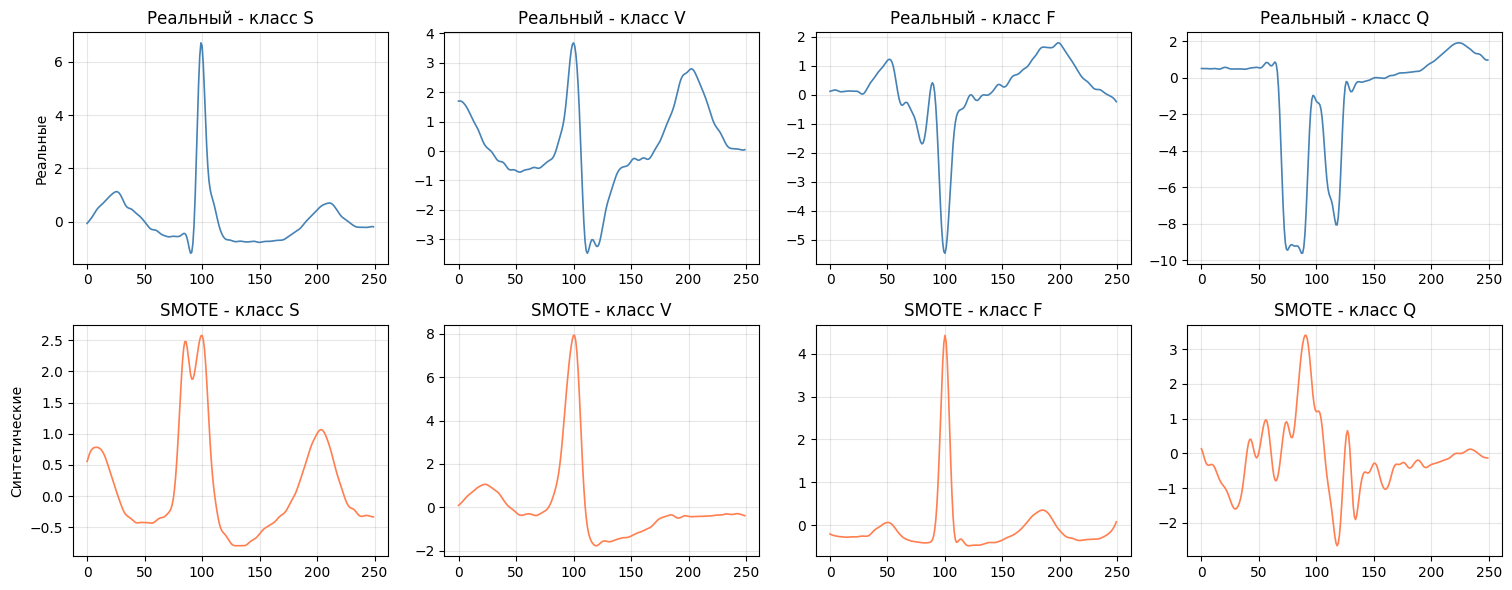

In [47]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))

for col, cls_idx in enumerate([1, 2, 3, 4]):  # S, V, F, Q
    # Реальный пример
    real_idx = np.where(y_train == cls_idx)[0]
    if len(real_idx) > 0:
        axes[0, col].plot(X_train[real_idx[0]], color='steelblue', linewidth=1.2)
        axes[0, col].set_title(f'Реальный - класс {CLASS_NAMES[cls_idx]}')
        axes[0, col].grid(alpha=0.3)
    
    # Синтетический пример (добавленный SMOTE)
    n_original = int(np.sum(y_train == cls_idx))
    synthetic_idx = np.where(y_train_smote == cls_idx)[0][n_original:]
    if len(synthetic_idx) > 0:
        axes[1, col].plot(X_train_smote[synthetic_idx[0]], color='coral', linewidth=1.2)
        axes[1, col].set_title(f'SMOTE - класс {CLASS_NAMES[cls_idx]}')
        axes[1, col].grid(alpha=0.3)

axes[0, 0].set_ylabel('Реальные')
axes[1, 0].set_ylabel('Синтетические')
plt.tight_layout()
plt.show()

## 5. Метод 2: Аугментации сигнала ЭКГ

В отличие от SMOTE, аугментации применяют **физически осмысленные искажения**, сохраняющие морфологию ЭКГ. Это более естественный подход для биомедицинских сигналов.

### Применяемые аугментации

| Аугментация | Описание | Параметры |
|-------------|----------|-----------|
| **Gaussian noise** | Добавление гауссова шума малой амплитуды | $\sigma \in [0.01, 0.05]$ |
| **Amplitude scaling** | Случайное масштабирование амплитуды | $s \in [0.85, 1.15]$ |
| **Time shift** | Циклический сдвиг сигнала во времени | $\pm 8$ отсчётов |
| **Baseline wander** | Имитация дрейфа изолинии (низкочастотный шум) | $f \in [0.1, 0.5]$ Гц |
| **Time warping** | Локальное растяжение/сжатие времени | $\sigma = 0.08$ |

Аугментация миноритарных классов:
  S: 944 → 15282 (+14338 аугментаций)
  V: 3788 → 15282 (+11494 аугментаций)
  F: 414 → 15282 (+14868 аугментаций)
  Q: 8 → 15282 (+15274 аугментаций)

После аугментаций:
-------------------------------------------------------
  N:   45847  (42.86%) █████████████████████
  S:   15282  (14.29%) ███████
  V:   15282  (14.29%) ███████
  F:   15282  (14.29%) ███████
  Q:   15282  (14.29%) ███████
-------------------------------------------------------
  Всего: 106975


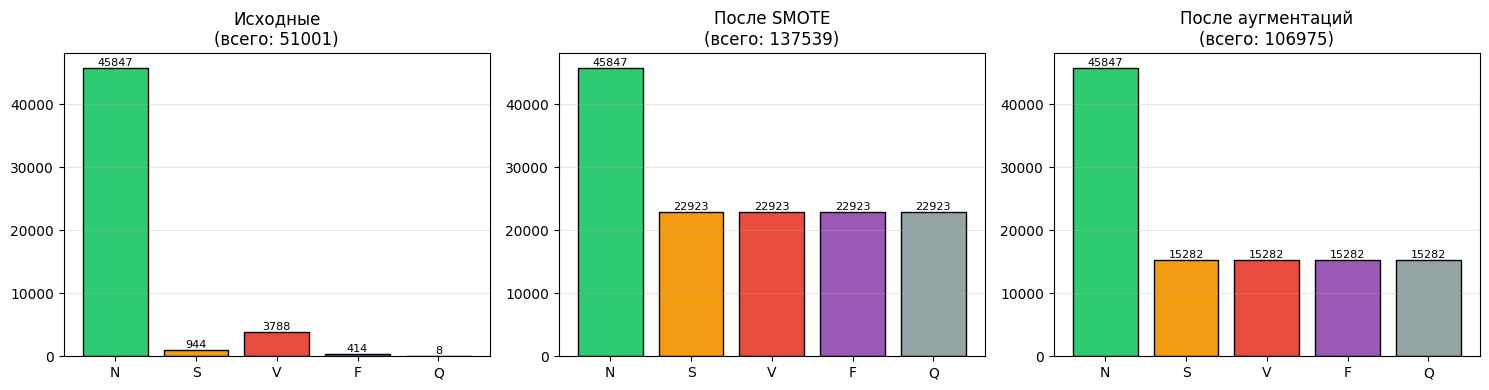

In [48]:
def add_gaussian_noise(signal, std=0.05):
    """Добавление гауссова шума, имитирует электронный шум."""
    noise = np.random.normal(0, std, signal.shape)
    return signal + noise


def amplitude_scale(signal, scale_range=(0.85, 1.15)):
    """Случайное масштабирование амплитуды (учитывает индивидуальные различия)."""
    scale = np.random.uniform(*scale_range)
    return signal * scale


def time_shift(signal, max_shift=8):
    """Циклический сдвиг во времени (имитация неточной локализации R-пика)."""
    shift = np.random.randint(-max_shift, max_shift + 1)
    return np.roll(signal, shift)


def baseline_wander(signal, max_amp=0.1, fs=FS):
    """
    Имитация низкочастотного дрейфа изолинии.
    Возникает из-за дыхания пациента или плохого контакта электродов.
    """
    t = np.arange(len(signal)) / fs
    freq = np.random.uniform(0.1, 0.5)
    amp = np.random.uniform(0, max_amp)
    phase = np.random.uniform(0, 2 * np.pi)
    wander = amp * np.sin(2 * np.pi * freq * t + phase)
    return signal + wander


def time_warp(signal, sigma=0.08, knots=4):
    """
    Локальное искажение временной шкалы.
    Имитирует естественные вариации длительности сердечного цикла.
    """
    orig_steps = np.arange(len(signal))
    random_warps = np.random.normal(1.0, sigma, knots + 2)
    warp_steps = np.linspace(0, len(signal) - 1, knots + 2)
    cs = CubicSpline(warp_steps, warp_steps * random_warps)
    new_steps = cs(orig_steps)
    new_steps = np.clip(new_steps, 0, len(signal) - 1)
    return np.interp(orig_steps, new_steps, signal)


def random_augment(signal, p=0.5):
    """
    Применяет случайную комбинацию аугментаций.
    Каждая аугментация применяется с вероятностью p.
    """
    sig = signal.copy()
    if np.random.rand() < p:
        sig = add_gaussian_noise(sig, std=np.random.uniform(0.01, 0.05))
    if np.random.rand() < p:
        sig = amplitude_scale(sig, (0.85, 1.15))
    if np.random.rand() < p:
        sig = time_shift(sig, max_shift=8)
    if np.random.rand() < p:
        sig = baseline_wander(sig, max_amp=0.08)
    if np.random.rand() < p * 0.5:  # time_warp применяем реже
        sig = time_warp(sig, sigma=0.08, knots=4)
    return sig


def augment_minority_classes(X, y, target_counts):
    """
    Аугментирует миноритарные классы до заданного числа примеров.
    
    Параметры:
    ----------
    X, y : данные
    target_counts : dict {class_idx: target_count}
    
    Возвращает:
    -----------
    X_out, y_out : расширенные и перемешанные массивы
    """
    X_aug = [X]
    y_aug = [y]
    
    for cls_idx, target in target_counts.items():
        cls_indices = np.where(y == cls_idx)[0]
        current = len(cls_indices)
        
        if current >= target:
            continue
        
        n_to_generate = target - current
        new_signals = np.zeros((n_to_generate, X.shape[1]), dtype=X.dtype)
        
        for i in range(n_to_generate):
            # Случайно выбираем существующий пример того же класса
            src_idx = np.random.choice(cls_indices)
            new_signals[i] = random_augment(X[src_idx], p=0.6)
        
        X_aug.append(new_signals)
        y_aug.append(np.full(n_to_generate, cls_idx))
        
        print(f'  {CLASS_NAMES[cls_idx]}: {current} → {target} (+{n_to_generate} аугментаций)')
    
    X_out = np.concatenate(X_aug, axis=0)
    y_out = np.concatenate(y_aug, axis=0)
    
    # Перемешивание
    perm = np.random.permutation(len(y_out))
    return X_out[perm], y_out[perm]


# Целевые значения: каждый миноритарный класс — до 1/3 от мажоритарного
n_majority = int(np.sum(y_train == 0))
target = n_majority // 3

target_counts = {
    1: max(target, int(np.sum(y_train == 1))),  # S
    2: max(target, int(np.sum(y_train == 2))),  # V
    3: max(target, int(np.sum(y_train == 3))),  # F
    4: max(target, int(np.sum(y_train == 4))),  # Q
}

print('Аугментация миноритарных классов:')
X_train_aug, y_train_aug = augment_minority_classes(
    X_train, y_train, target_counts
)

print_distribution(y_train_aug, 'После аугментаций')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Исходные', 'После SMOTE', 'После аугментаций']
data_sets = [y_train, y_train_smote, y_train_aug]
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#95a5a6']

for ax, title, y_data in zip(axes, titles, data_sets):
    counts = [np.sum(y_data == i) for i in range(5)]
    ax.bar(CLASS_NAMES, counts, color=colors, edgecolor='black')
    ax.set_title(f'{title}\n(всего: {len(y_data)})')
    ax.grid(axis='y', alpha=0.3)
    for i, c in enumerate(counts):
        ax.text(i, c, f'{c}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


### Демонстрация каждой аугментации

Применим каждый тип аугментации к одному сигналу и сравним с оригиналом.

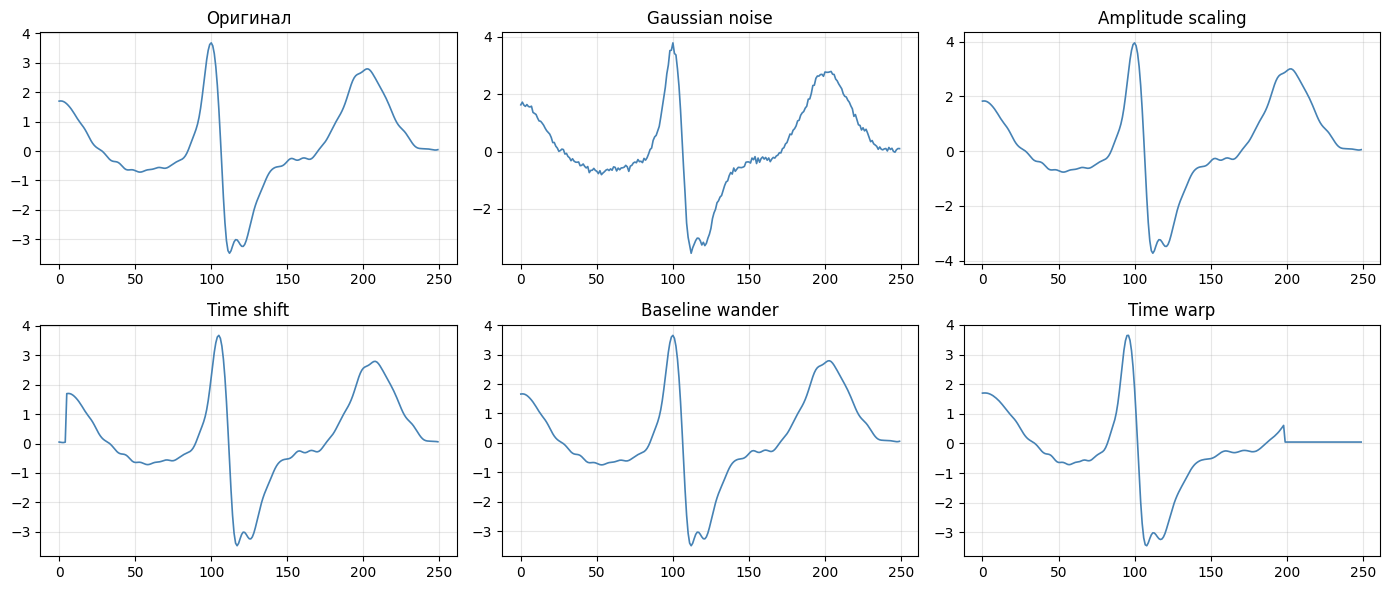

In [49]:
# Берём один пример класса V и применяем разные аугментации
v_idx = np.where(y_train == 2)[0][0]
original = X_train[v_idx]

augmentations = {
    'Оригинал': original,
    'Gaussian noise': add_gaussian_noise(original, std=0.05),
    'Amplitude scaling': amplitude_scale(original, (0.85, 1.15)),
    'Time shift': time_shift(original, max_shift=8),
    'Baseline wander': baseline_wander(original, max_amp=0.1),
    'Time warp': time_warp(original, sigma=0.08, knots=4),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, (name, sig) in zip(axes.flat, augmentations.items()):
    ax.plot(sig, color='steelblue', linewidth=1.2)
    ax.set_title(name)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Метод 3: Вычисление весов классов

Веса для **взвешенной функции потерь** обратно пропорциональны частоте класса:

$$w_c = \frac{N}{K \cdot n_c}$$

где $N$ - общее количество, $K$ - число классов, $n_c$ - количество в классе $c$.

In [50]:
def compute_weights(y, method='balanced'):
    """
    Вычисляет веса классов.
    
    method:
      'balanced' ? N / (K * n_c)  [стандартный sklearn]
      'inverse'  ? 1 / n_c        [простая обратная частота]
      'sqrt'     ? 1 / sqrt(n_c)  [смягчённые веса]
    """
    classes = np.unique(y)
    counts = np.array([np.sum(y == c) for c in classes])
    
    if method == 'balanced':
        weights = len(y) / (len(classes) * counts)
    elif method == 'inverse':
        weights = 1.0 / counts
    elif method == 'sqrt':
        weights = 1.0 / np.sqrt(counts)
    else:
        raise ValueError(f'Unknown method: {method}')
    
    # Нормализация: средний вес = 1
    weights = weights / weights.mean()
    return weights.astype(np.float32)


# Веса на ИСХОДНЫХ несбалансированных данных (для использования с loss)
class_weights = compute_weights(y_train, method='balanced')

print('Веса классов (для loss):')
for i, (name, w) in enumerate(zip(CLASS_NAMES, class_weights)):
    print(f'  {name}: {w:.3f}')

# Sample weights ? вес каждого примера, для WeightedRandomSampler
sample_weights = class_weights[y_train]
print(f'\nshape sample_weights: {sample_weights.shape}')

Веса классов (для loss):
  N: 0.001
  S: 0.041
  V: 0.010
  F: 0.094
  Q: 4.854

shape sample_weights: (51001,)


## 7. Сохранение всех данных для обучения модели

Сохраняем **три варианта** обучающей выборки + тестовую выборку + веса классов.
Это позволит легко сравнить разные стратегии в ноутбуке обучения модели.

In [51]:
# Сохраняем всё в один файл
np.savez_compressed(
    './models/mitbih_balanced.npz',
    
    # === Исходная (несбалансированная) обучающая выборка ===
    X_train=X_train.astype(np.float32),
    y_train=y_train.astype(np.int64),
    
    # === Вариант 1: после SMOTE ===
    X_train_smote=X_train_smote.astype(np.float32),
    y_train_smote=y_train_smote.astype(np.int64),
    
    # === Вариант 2: после аугментаций ===
    X_train_aug=X_train_aug.astype(np.float32),
    y_train_aug=y_train_aug.astype(np.int64),
    
    # === Тестовая выборка (НЕ балансируется!) ===
    X_test=X_test.astype(np.float32),
    y_test=y_test.astype(np.int64),
    
    # === Веса классов для loss ===
    class_weights=class_weights.astype(np.float32),
    
    # === Веса примеров для WeightedRandomSampler ===
    sample_weights=sample_weights.astype(np.float32),
    
    # === Метаинформация ===
    class_names=np.array(CLASS_NAMES),
    fs=np.int32(FS),
)

print(' Данные сохранены в mitbih_balanced.npz')

import os
size_mb = os.path.getsize('./models/mitbih_balanced.npz') / 1024 / 1024
print(f'  Размер файла: {size_mb:.1f} МБ')

 Данные сохранены в mitbih_balanced.npz
  Размер файла: 297.8 МБ


### Проверка сохранённых данных

In [52]:
# Проверим, что всё корректно загружается
check = np.load('./models/mitbih_balanced.npz', allow_pickle=True)

print('Содержимое файла mitbih_balanced.npz:')
print('=' * 60)
for key in check.files:
    arr = check[key]
    if arr.ndim == 0:
        print(f'  {key:20s} | scalar    | {arr}')
    else:
        print(f'  {key:20s} | {str(arr.shape):15s} | dtype={arr.dtype}')
print('=' * 60)

print('\nВеса классов:')
for name, w in zip(check['class_names'], check['class_weights']):
    print(f'  {name}: {w:.3f}')

Содержимое файла mitbih_balanced.npz:
  X_train              | (51001, 250)    | dtype=float32
  y_train              | (51001,)        | dtype=int64
  X_train_smote        | (137539, 250)   | dtype=float32
  y_train_smote        | (137539,)       | dtype=int64
  X_train_aug          | (106975, 250)   | dtype=float32
  y_train_aug          | (106975,)       | dtype=int64
  X_test               | (49691, 250)    | dtype=float32
  y_test               | (49691,)        | dtype=int64
  class_weights        | (5,)            | dtype=float32
  sample_weights       | (51001,)        | dtype=float32
  class_names          | (5,)            | dtype=<U1
  fs                   | scalar    | 360

Веса классов:
  N: 0.001
  S: 0.041
  V: 0.010
  F: 0.094
  Q: 4.854
